In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torch import nn

In [21]:
train_data = MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = MNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

In [22]:
img, label = train_data[0]
img.shape, len(train_data)

(torch.Size([1, 28, 28]), 60000)

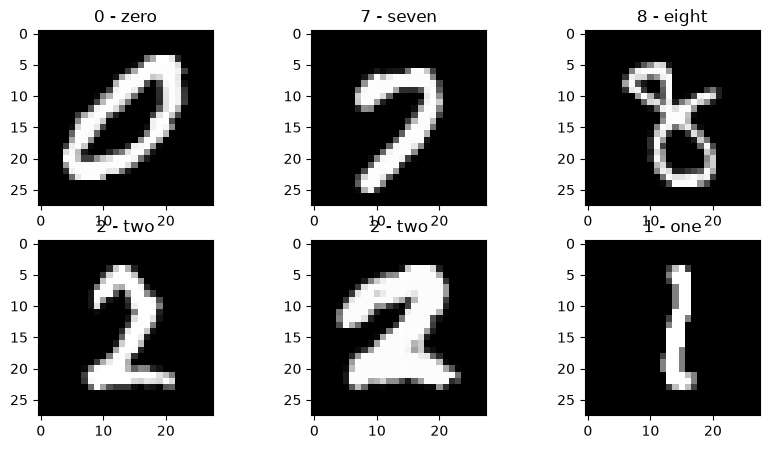

In [29]:
class_names = train_data.classes
plt.figure(figsize=(10,5))
cols = 3
rows = 2

for i in range(cols * rows):
    rand_int = torch.randint(low=0, high=len(train_data), size=[1]).item()
    img, label = train_data[rand_int]
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])

In [30]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32)


In [34]:
class MNISTClassifierV0(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer_3 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
        )
    def forward(self, x):
        x = self.layer_1(x)
        x = self.layer_2(x)
        x = self.layer_3(x)
        return x

model_0 = MNISTClassifierV0(input_shape=1, hidden_units=10, output_shape=len(class_names))